## 패키지 선언

In [2]:
import torch
import torch.nn as nn
import torchvision.datasets as dataset
import torchvision.transforms as transform
from torch.utils.data import DataLoader

## Dataset 선언

In [9]:
# Training dataset 다운로드
mnist_train = dataset.MNIST(root = "./" , # 데이터셋을 저장할 위치(현재 경로에 다운받겠다)
                            train = True, #train 데이터셋인지, test 데이터 셋인지
                            transform = transform.ToTensor(),
                            download = True)
# Testing dataset 다운로드
mnist_test = dataset.MNIST(root = "./",
                            train = False,
                            transform = transform.ToTensor(),
                            download = True)

## MNIST 데이터셋 형상 확인

60000
torch.Size([1, 28, 28])
5


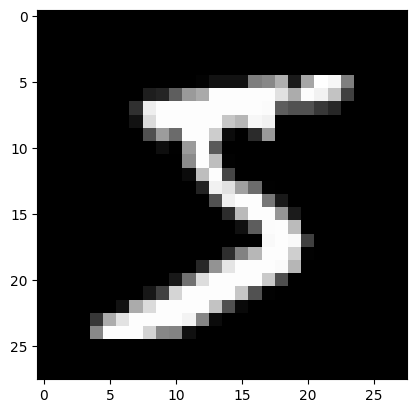

In [4]:
import matplotlib.pyplot as plt
print(len(mnist_train))     # training dataset 개수 확인

first_data = mnist_train[0]
print(first_data[0].shape)  # 첫번째 data의 형상 확인
print(first_data[1])        # 첫번째 data의 정답 확인

plt.imshow(first_data[0][0,:,:], cmap='gray')
plt.show()

In [5]:
first_img = first_data[0]
print(first_img.shape)

first_img = first_img.view(-1, 28*28) # 이미지 평탄화 수행 2D -> 1D
print(first_img.shape)

torch.Size([1, 28, 28])
torch.Size([1, 784])


## Single Layer Perceptron 모델 정의

In [15]:
class SLP (nn.Module):
  def __init__ (self):
    super(SLP, self).__init__()

    self.fc = nn.Linear(in_features = 784, out_features = 10) #레이어 선언(입력은 784개, 출력은 10개)

  def forward(self, x): #실행할 함수
    x = x.view(-1, 28*28) #28*28컬럼 벡터를 만들어줬는데 어떻게 배치가 되는지 모르기 때문에 평탄화작업(한 이미지를 학습하는게 아닌 여러 이미지를 학습하는데 2차원이라서 1차원으로 만들어주고 계산하는 함수 view)
    y = self.fc(x) #10개 클래스의 확률값이 출력으로 나옴

    return y

## Hyper-parameters 지정

In [16]:
batch_size = 100
learning_rate = 0.1
training_epochs = 15
loss_function = nn.CrossEntropyLoss() #10개 클래스에 대한 확률을 자동으로 확률로 변환해주는 함수
network = SLP()
optimizer = torch.optim.SGD(network.parameters(), lr = learning_rate)

data_loader = DataLoader(dataset=mnist_train, #다운받았던 데이터를 받음
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True)

## Perceptron 학습을 위한 반복문 선언

In [17]:
for epoch in range(training_epochs): #한 에폭마다 반복
  avg_cost = 0
  total_batch = len(data_loader)

  for img, label in data_loader:

    pred = network(img)

    loss = loss_function(pred, label)
    optimizer.zero_grad() # gradient 초기화
    loss.backward() #편미분해서 weight 값 계산
    optimizer.step()

    avg_cost += loss / total_batch

  print('Epoch: %d Loss = %f'%(epoch+1, avg_cost))

print('Learning finished')

Epoch: 1 Loss = 0.536755
Epoch: 2 Loss = 0.359464
Epoch: 3 Loss = 0.331158
Epoch: 4 Loss = 0.316072
Epoch: 5 Loss = 0.306994
Epoch: 6 Loss = 0.300214
Epoch: 7 Loss = 0.294816
Epoch: 8 Loss = 0.290739
Epoch: 9 Loss = 0.287200
Epoch: 10 Loss = 0.284269
Epoch: 11 Loss = 0.281929
Epoch: 12 Loss = 0.279597
Epoch: 13 Loss = 0.277769
Epoch: 14 Loss = 0.275957
Epoch: 15 Loss = 0.274264
Learning finished


## 학습이 완료된 모델을 이용해 정답률 확인

In [18]:
with torch.no_grad(): # test에서는 기울기 계산 제외

  img_test = mnist_test.data.float()
  label_test = mnist_test.targets

  prediction = network(img_test) # 전체 test data를 한번에 계산

  correct_prediction = torch.argmax(prediction, 1) == label_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

Accuracy: 0.8942999839782715


## Weight parameter 저장하기/불러오기

In [ ]:
torch.save(network.state_dict(), "./slp_mnist.pth")